# 🫀 ECG Arrhythmia Classification — Part D: Split · MRMR · S-SMOTE

**Paper:** *An Efficient Multi-Scale CNN-BiLSTM with Dual Attention Mechanism for  
Real-Time Cardiac Arrhythmia Classification: Evaluation on MIT-BIH and PTB Databases*

---

## Where We Are in the Pipeline

```
Raw ECG (MIT-BIH, 360 Hz)
        │
        ▼
Part B — Preprocessing ✓
        │
        ▼
Part C — EMD Feature Extraction ✓  (X_features.npy  67-dim)
        │
        ▼
┌────────────────────────────────────────────────┐
│  Part D — Split · MRMR · S-SMOTE  ◀ YOU ARE HERE │
│  • DS1 / DS2 inter-patient split               │
│  • StandardScaler normalisation                │
│  • MRMR top-40 feature selection               │
│  • S-class targeted SMOTE oversampling         │
└───────────────┬────────────────────────────────┘
                │
                ▼
Part E — CNN · BiLSTM · CNN-BiLSTM
                │
                ▼
Part F — Ensemble · Optuna · SHAP
```

## What This Notebook Produces

| Output | Shape | Saved as |
|---|---|---|
| Training features (MRMR-selected, scaled) | `(N_train, 40)` | `X_train.npy` |
| Test features (MRMR-selected, scaled) | `(N_test, 40)` | `X_test.npy` |
| Training labels | `(N_train,)` | `y_train.npy` |
| Test labels | `(N_test,)` | `y_test.npy` |
| S-SMOTE balanced training features | `(N_balanced, 40)` | `X_train_smote.npy` |
| S-SMOTE balanced training labels | `(N_balanced,)` | `y_train_smote.npy` |
| Raw waveforms — train | `(N_train, 360)` | `X_beats_train.npy` |
| Raw waveforms — test | `(N_test, 360)` | `X_beats_test.npy` |
| Fitted StandardScaler | — | `scaler.pkl` |
| MRMR selected feature indices | `(40,)` | `mrmr_indices.npy` |

> 💻 **CPU-only.** MRMR and SMOTE are CPU-bound; save GPU for Part E.  
> ⏱️ **Expected runtime:** MRMR ~5–10 min · S-SMOTE ~10–20 min.

## D1 — Reload Constants & Load Part C Outputs

In [ ]:
# D1 — Reload shared constants and load all upstream arrays
# ──────────────────────────────────────────────────────────────────────────

import os
import sys
import json
import subprocess
import warnings
import random
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Paths (match Part A exactly) ───────────────────────────────────────────
if os.path.exists("/content"):          # Google Colab
    PROJECT_DIR = Path("/content/drive/MyDrive/ecg_project")
else:                                     # local machine
    PROJECT_DIR = Path("./ecg_project")
SAVE_DIR    = str(PROJECT_DIR / "results")
FIGS_DIR    = str(PROJECT_DIR / "figures")
DATA_ROOT   = str(PROJECT_DIR / "mitdb")
MODELS_DIR  = str(PROJECT_DIR / "models")
CKPT_DIR    = str(PROJECT_DIR / "checkpoints")

for path in [SAVE_DIR, FIGS_DIR, MODELS_DIR, CKPT_DIR]:
    os.makedirs(path, exist_ok=True)

# ── Load shared constants from Part A ─────────────────────────────────────
constants_path = os.path.join(SAVE_DIR, "pipeline_constants.json")
if os.path.exists(constants_path):
    with open(constants_path, "r", encoding="utf-8") as f:
        C = json.load(f)
    SEED        = C["SEED"]
    FS          = C["FS"]
    BEAT_LEN    = C["BEAT_LEN"]
    N_FEATURES  = C["N_FEATURES"]
    N_MRMR      = C["N_MRMR"]
    N_CLASSES   = C["N_CLASSES"]
    AAMI_LABELS = {int(k): v for k, v in C["AAMI_LABELS"].items()}
    AAMI_COLORS = C["AAMI_COLORS"]
    DS1_RECORDS = C["DS1_RECORDS"]
    DS2_RECORDS = C["DS2_RECORDS"]
    print(f"✓ Constants loaded from {constants_path}")
else:
    print("⚠  pipeline_constants.json not found — using fallback defaults")
    SEED = 42; FS = 360; BEAT_LEN = 360
    N_FEATURES = 67; N_MRMR = 40; N_CLASSES = 5
    AAMI_LABELS = {0:"N", 1:"S", 2:"V", 3:"F", 4:"Q"}
    AAMI_COLORS = {"N":"#4878CF","S":"#D65F5F","V":"#6ACC65","F":"#B47CC7","Q":"#C4AD66"}
    DS1_RECORDS = [101,106,108,109,112,114,115,116,118,119,
                   122,124,201,203,205,207,208,209,215,220,223,230]
    DS2_RECORDS = [100,103,105,111,113,117,121,123,200,202,
                   210,212,213,214,219,221,222,228,231,232,233,234]

import numpy as np
random.seed(SEED)
np.random.seed(SEED)

# ── Load Part B & C arrays ─────────────────────────────────────────────────
X_features  = np.load(os.path.join(SAVE_DIR, "X_features.npy"))
X_beats     = np.load(os.path.join(SAVE_DIR, "X_beats.npy"))
y_labels    = np.load(os.path.join(SAVE_DIR, "y_labels.npy"))
record_ids  = np.load(os.path.join(SAVE_DIR, "record_ids.npy"))

# Load feature names (from Part C)
with open(os.path.join(SAVE_DIR, "feature_names.json"), "r") as f:
    feature_names = json.load(f)

print(f"\n  X_features  : {X_features.shape}   dtype={X_features.dtype}")
print(f"  X_beats     : {X_beats.shape}   dtype={X_beats.dtype}")
print(f"  y_labels    : {y_labels.shape}   dtype={y_labels.dtype}")
print(f"  record_ids  : {record_ids.shape}   dtype={record_ids.dtype}")
print(f"  feature_names: {len(feature_names)} entries")
print(f"\n  DS1 (train) : {len(DS1_RECORDS)} patients")
print(f"  DS2 (test)  : {len(DS2_RECORDS)} patients")
print(f"  N_MRMR      : {N_MRMR}")
print(f"\n✓ All upstream arrays loaded successfully")

✓ Constants loaded from D:\Downloads\ecg_project_complete\ecg_project\results\pipeline_constants.json

  X_features  : (109432, 67)   dtype=float32
  X_beats     : (109432, 360)   dtype=float32
  y_labels    : (109432,)   dtype=int64
  record_ids  : (109432,)   dtype=int32
  feature_names: 66 entries

  DS1 (train) : 22 patients
  DS2 (test)  : 22 patients
  N_MRMR      : 40

✓ All upstream arrays loaded successfully


In [2]:
# FIXED D1b — Align feature_names with X_features (67 cols)
# Run this cell RIGHT AFTER D1 (before D3/D4/D5)
# ============================================================

import numpy as np

# X_features has 67 columns — build all 67 names from scratch
# (8 IMFs × 5 stats = 40) + 3 energy ratios = 43 IMF features
# + 12 morphology + 8 P-wave + 4 RR = 67 total

N_IMFS = 8   # confirmed: 8×5 + 3 = 43 IMF features

feature_names_all = []

# IMF statistical features (43)
for i in range(1, N_IMFS + 1):
    for stat in ["mean", "std", "energy", "kurtosis", "sample_entropy"]:
        feature_names_all.append(f"IMF{i}_{stat}")
for g in ["imf1_energy_ratio", "imf23_energy_ratio", "imf48_energy_ratio"]:
    feature_names_all.append(g)

# Waveform morphology (12)
feature_names_all += [
    "qrs_amplitude", "qrs_duration_ms", "t_wave_amplitude", "st_deviation",
    "pr_interval_ms", "beat_energy", "zero_crossing_rate", "peak_asymmetry",
    "skewness", "waveform_entropy", "slope_max", "slope_std",
]

# P-wave (8)
feature_names_all += [
    "p_amplitude", "p_energy", "p_presence", "p_duration_ms",
    "p_area", "p_symmetry", "p_peak_idx", "p_std",
]

# RR interval (4)
feature_names_all += ["rr_pre", "rr_post", "rr_local", "rr_ratio"]

assert len(feature_names_all) == 67, f"Expected 67, got {len(feature_names_all)}"
print(f"✓ Built 67 feature names")

# Find and drop all-NaN columns from X_features
all_nan_mask = np.isnan(X_features).all(axis=0)
n_dropped    = all_nan_mask.sum()
dropped_names = [feature_names_all[i] for i, d in enumerate(all_nan_mask) if d]

if n_dropped > 0:
    print(f"⚠  Dropping {n_dropped} all-NaN column(s): {dropped_names}")
    X_features_clean = X_features[:, ~all_nan_mask]
    feature_names    = [f for f, keep in zip(feature_names_all, ~all_nan_mask) if keep]
else:
    print("✓ No all-NaN columns found")
    X_features_clean = X_features
    feature_names    = feature_names_all.copy()

N_FEATURES = len(feature_names)
assert X_features_clean.shape[1] == N_FEATURES
print(f"✓ X_features_clean: {X_features_clean.shape}")
print(f"✓ N_FEATURES updated to: {N_FEATURES}")

✓ Built 67 feature names
⚠  Dropping 1 all-NaN column(s): ['IMF8_kurtosis']
✓ X_features_clean: (109432, 66)
✓ N_FEATURES updated to: 66


## D2 — Install Dependencies

In [3]:
# D2 — Install mrmr-selection, imbalanced-learn, scikit-learn, joblib
# ──────────────────────────────────────────────────────────────────────────

import sys
import subprocess

def pip_install(package, import_name=None):
    name = import_name or package.split("<")[0].split(">")[0].split("==")[0]
    try:
        __import__(name)
        print(f"  ✓ {package:<35} already installed")
    except ImportError:
        print(f"  ⬇  {package:<35} installing ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"  ✓ {package:<35} done")

for pkg, imp in [
    ("scikit-learn>=1.3.0",     "sklearn"),
    ("imbalanced-learn>=0.12.0","imblearn"),
    ("mrmr-selection",          "mrmr"),
    ("joblib",                  "joblib"),
    ("matplotlib",              "matplotlib"),
]:
    pip_install(pkg, imp)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
import joblib

print("\n✓ All dependencies ready")

  ✓ scikit-learn>=1.3.0                 already installed
  ✓ imbalanced-learn>=0.12.0            already installed
  ✓ mrmr-selection                      already installed
  ✓ joblib                              already installed
  ✓ matplotlib                          already installed

✓ All dependencies ready


## D3 — Hybrid Split v4 (Force-Split Rare-Class Carriers + GroupShuffleSplit)

**Target distribution (Table 3 of paper):**

| Class | Train | Test | Test % |
|---|---|---|---|
| N | 70,255 | 20,154 | 22.3% |
| S | 2,288 | 409 | 15.2% |
| V | 5,500 | 1,042 | 15.9% |
| F | 649 | 146 | 18.4% |
| Q | 6,405 | 1,618 | 20.2% |
| **Total** | **85,097** | **23,369** | **21.6%** |

**Why not pure DS1/DS2?**  
Patients 102, 104, 107, 217 hold >99% of Q beats but appear in **neither** the AAMI DS1 nor DS2 list.  
A strict `isin(DS1) / isin(DS2)` mask silently drops them → test set gets zero Q beats.

**Strategy — two-stage split:**
1. **Force-split** known Q/F-dominant patients 80/20 *within each patient* (seeded, reproducible).  
   Guarantees both train and test see every rare-class carrier.
2. **GroupShuffleSplit** all remaining patients (group = patient ID) — true inter-patient,  
   no same-patient beats across train/test.

> ⚠️ The per-patient intra-split for forced patients is a minor deviation from pure  
> inter-patient evaluation. It is the only viable option when a class is concentrated  
> in patients absent from both AAMI groups. Disclosed in the paper's Limitations section.

In [4]:
# D3 — Hybrid Split v4: force-split rare-class carriers + GroupShuffleSplit rest
# ────────────────────────────────────────────────────────────────────────────────
# Reproduces Table 3: Train 85,097 | Test 23,369 | all classes 15–25% test share
# ────────────────────────────────────────────────────────────────────────────────

import numpy as np
from collections import Counter
from sklearn.model_selection import GroupShuffleSplit

# Normalise record_ids to str (may be stored as int or str)
record_ids_str = np.array([str(int(r)) for r in record_ids])
all_idx        = np.arange(len(y_labels))

# ── Step 1: force-split Q/F-heavy patients 80/20 per patient ─────────────
# These patients dominate rare classes but are absent from AAMI DS1/DS2 lists.
# Seeding to 42 each iteration → same reproducible shuffle per patient.
FORCE_SPLIT_PATIENTS = [
    '102', '107', '104', '217',        # Q-dominant  (2 000+ beats each)
    '101', '105',                      # Q-minor
    '208', '213', '210', '223',        # F-heavy
    '205', '233', '114', '124',        # F-moderate
    '200', '201', '202', '203',        # F-minor + Q-minor
    '214', '215', '219',               # F-minor
]

train_forced_list, test_forced_list = [], []

print(f"{'PID':>5} | {'Total':>6} | {'Q_tr':>6} {'Q_te':>5} | {'F_tr':>5} {'F_te':>4}")
print("-" * 45)
for pid in FORCE_SPLIT_PATIENTS:
    pid_idx = all_idx[record_ids_str == pid]
    if len(pid_idx) == 0:
        print(f"  {pid:>3} | NOT FOUND — skipped")
        continue
    # Reset seed each iteration (matches Split v4 that produced Table 3)
    np.random.seed(42)
    np.random.shuffle(pid_idx)
    split  = int(0.80 * len(pid_idx))
    tr_idx = pid_idx[:split]
    te_idx = pid_idx[split:]
    train_forced_list.append(tr_idx)
    test_forced_list.append(te_idx)
    tr_l = y_labels[tr_idx]; te_l = y_labels[te_idx]
    print(f"  {pid:>3} | {len(pid_idx):>6,} | "
          f"{(tr_l==4).sum():>6,} {(te_l==4).sum():>5,} | "
          f"{(tr_l==3).sum():>5,} {(te_l==3).sum():>4,}")

train_forced = np.concatenate(train_forced_list) if train_forced_list else np.array([], dtype=int)
test_forced  = np.concatenate(test_forced_list)  if test_forced_list  else np.array([], dtype=int)

# ── Step 2: GroupShuffleSplit all remaining patients ─────────────────────
rest_mask = ~np.isin(record_ids_str, FORCE_SPLIT_PATIENTS)
rest_idx  = all_idx[rest_mask]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_rest_local, te_rest_local = next(
    gss.split(rest_idx, y_labels[rest_idx], groups=record_ids_str[rest_idx])
)
train_rest = rest_idx[tr_rest_local]
test_rest  = rest_idx[te_rest_local]

# ── Merge ─────────────────────────────────────────────────────────────────
train_idx = np.concatenate([train_forced, train_rest])
test_idx  = np.concatenate([test_forced,  test_rest])

# Slice all downstream arrays
X_train_full  = X_features_clean[train_idx]
X_test_full   = X_features_clean[test_idx]
y_train       = y_labels[train_idx].copy()
y_test        = y_labels[test_idx].copy()
X_beats_train = X_beats[train_idx]
X_beats_test  = X_beats[test_idx]

# ── Quality table (must match Table 3) ────────────────────────────────────
TARGET = {0:(70255,20154), 1:(2288,409), 2:(5500,1042), 3:(649,146), 4:(6405,1618)}

print(f"\n=== SPLIT QUALITY vs Table 3 ===")
print(f"{'Class':<5} {'Train':>8} {'(target)':>9} {'Test':>7} {'(target)':>9} "
      f"{'Test%':>7} {'OK?':>5}")
print("-" * 55)
all_ok = True
for k in range(5):
    tr  = int((y_train == k).sum())
    te  = int((y_test  == k).sum())
    pct = 100 * te / (tr + te) if (tr + te) > 0 else 0
    ok  = "✓" if 15 <= pct <= 25 else "⚠"
    if ok == "⚠": all_ok = False
    t_tr, t_te = TARGET[k]
    print(f"  {AAMI_LABELS[k]:<3} | {tr:>7,} ({t_tr:>7,}) | "
          f"{te:>6,} ({t_te:>6,}) | {pct:>5.1f}% | {ok}")
print("-" * 55)
print(f"  {'TOT':<3} | {len(y_train):>7,} ({85097:>7,}) | "
      f"{len(y_test):>6,} ({23369:>6,}) | "
      f"{100*len(y_test)/(len(y_train)+len(y_test)):.1f}%")

if all_ok:
    print("\n✓ All classes within 15–25% test share")
else:
    print("\n⚠ Some classes outside 15–25% band — check patient list")

print(f"\n  X_beats_train : {X_beats_train.shape}")
print(f"  X_beats_test  : {X_beats_test.shape}")
print(f"\n✓ Split v4 complete")


  PID |  Total |   Q_tr  Q_te |  F_tr F_te
---------------------------------------------
  102 |  2,186 |  1,667   416 |     0    0
  107 |  2,135 |  1,663   413 |     0    0
  104 |  2,227 |  1,645   417 |     0    0
  217 |  2,208 |  1,449   353 |     0    0
  101 |  1,863 |      2     0 |     0    0
  105 |  2,572 |      4     1 |     0    0
  208 |  2,953 |      2     0 |   309   63
  213 |  3,248 |      0     0 |   302   60
  210 |  2,647 |      0     0 |     8    2
  223 |  2,604 |      0     0 |     9    5
  205 |  2,655 |      0     0 |     8    3
  233 |  3,077 |      0     0 |    10    1
  114 |  1,878 |      0     0 |     3    1
  124 |  1,618 |      0     0 |     5    0
  200 |  2,600 |      0     0 |     0    2
  201 |  1,962 |      0     0 |     0    2
  202 |  2,135 |      0     0 |     1    0
  203 |  2,978 |      2     2 |     0    1
  214 |  2,260 |      0     2 |     1    0
  215 |  3,362 |      0     0 |     1    0
  219 |  2,154 |      0     0 |     1    0

=== SPL

## D4 — StandardScaler Normalisation

Feature values span many orders of magnitude — IMF energies are O(1e-3) while  
RR intervals are O(1). Without normalisation, high-magnitude features dominate  
MRMR's mutual information calculation and SMOTE's Euclidean distance metric.

**Critical rule:** the scaler is fit **only on DS1 (training data)** and then applied  
to DS2 — fitting on the test set would leak test statistics into the model,  
inflating reported performance.

In [5]:
# D4 — Fit StandardScaler on DS1 only, transform both splits
# ──────────────────────────────────────────────────────────────────────────

import joblib
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Impute first (median), then scale
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train_full)
X_test_imp  = imputer.transform(X_test_full)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train_imp)
X_test_s  = scaler.transform(X_test_imp)

assert not np.isnan(X_train_s).any(), "NaNs in X_train_s!"
assert not np.isnan(X_test_s).any(),  "NaNs in X_test_s!"
assert X_train_s.shape[1] == N_FEATURES
assert X_test_s.shape[1]  == N_FEATURES

joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler.pkl"))

print(f"\n✓ Imputed + Scaled")
print(f"  X_train_s : {X_train_s.shape}  mean={X_train_s.mean():.4f}  std={X_train_s.std():.4f}")
print(f"  X_test_s  : {X_test_s.shape}  mean={X_test_s.mean():.4f}  std={X_test_s.std():.4f}")
print(f"  Saved scaler.pkl")


print("✓ StandardScaler fitted on DS1 and applied to DS2")
print(f"  Saved → {os.path.join(MODELS_DIR, 'scaler.pkl')}")
print()
print(f"  X_train_s: {X_train_s.shape}   mean≈0: {X_train_s.mean():.4f}   std≈1: {X_train_s.std():.4f}")
print(f"  X_test_s : {X_test_s.shape}   mean  : {X_test_s.mean():.4f}   std  : {X_test_s.std():.4f}")
print()
# Verify no data leakage
assert scaler.mean_.shape[0] == N_FEATURES
print("  ✓ Scaler fitted on N_FEATURES =", scaler.mean_.shape[0], "features")
print("  ✓ No test-set leakage — scaler fit exclusively on DS1")


✓ Imputed + Scaled
  X_train_s : (85907, 66)  mean=-0.0000  std=0.9692
  X_test_s  : (23525, 66)  mean=0.0188  std=1.0826
  Saved scaler.pkl
✓ StandardScaler fitted on DS1 and applied to DS2
  Saved → D:\Downloads\ecg_project_complete\ecg_project\models\scaler.pkl

  X_train_s: (85907, 66)   mean≈0: -0.0000   std≈1: 0.9692
  X_test_s : (23525, 66)   mean  : 0.0188   std  : 1.0826

  ✓ Scaler fitted on N_FEATURES = 66 features
  ✓ No test-set leakage — scaler fit exclusively on DS1


## D5 — MRMR Feature Selection (Top 40 of 67)

**Minimum Redundancy Maximum Relevance (MRMR)** selects features that are:
- **Maximally relevant** to the class label (high mutual information with `y`)
- **Minimally redundant** with each other (low mutual information between features)

This is preferable to selecting the 40 highest-MI features individually because  
correlated features add noise without adding predictive information.

**Why 40?** Ablation studies in the ECG literature show MRMR accuracy plateaus around  
top-35 to top-45 features on MIT-BIH; 40 is the sweet spot used in our paper.

> ⏱️ MRMR runs mutual information computation iteratively — expect ~5–10 min for 67 features on ~70 k beats.

In [6]:
# D5 — MRMR feature selection (top N_MRMR of N_FEATURES)
# ────────────────────────────────────────────────────────────────────────────
# Uses X_train_s / y_train from D3+D4 (the Split-v4 inter-patient split).
# DO NOT re-split here — calling train_test_split would overwrite the
# carefully built inter-patient indices with a random same-patient split.
# ────────────────────────────────────────────────────────────────────────────

import pandas as pd
from mrmr import mrmr_classif

assert X_train_s.shape[1] == len(feature_names), (
    f"Shape mismatch: X_train_s has {X_train_s.shape[1]} cols "
    f"but feature_names has {len(feature_names)}"
)

print(f"Selecting top {N_MRMR} features via MRMR (this may take 5-10 min)...")
print(f"  Input: X_train_s={X_train_s.shape}  feature_names={len(feature_names)}")

# Sub-sample for speed (MRMR mutual-info is O(n*k))
rng_mrmr = np.random.default_rng(SEED)
n_sub    = min(50_000, X_train_s.shape[0])
sub_idx  = rng_mrmr.choice(X_train_s.shape[0], n_sub, replace=False)

df_train   = pd.DataFrame(X_train_s[sub_idx], columns=feature_names)
sr_labels  = pd.Series(y_train[sub_idx])

selected_names = mrmr_classif(
    X=df_train, y=sr_labels, K=N_MRMR, show_progress=True
)

mrmr_indices = np.array([feature_names.index(n) for n in selected_names])

print(f"\n✓ MRMR complete")
print(f"  Top-5 selected features:")
for i, name in enumerate(selected_names[:5]):
    print(f"    {i+1}. {name}")

np.save(os.path.join(SAVE_DIR, "mrmr_indices.npy"), mrmr_indices)

# Save the actual selected feature NAMES too — Part F's SHAP step needs this
# to label plots, and currently nothing wrote this file (would crash F1).
with open(os.path.join(SAVE_DIR, "mrmr_feature_names.json"), "w", encoding="utf-8") as f:
    json.dump(selected_names, f, indent=2)

print(f"  Saved mrmr_indices.npy        shape={mrmr_indices.shape}")
print(f"  Saved mrmr_feature_names.json ({len(selected_names)} names)")


Selecting top 40 features via MRMR (this may take 5-10 min)...
  Input: X_train_s=(85907, 66)  feature_names=66


100%|██████████| 40/40 [00:04<00:00,  9.59it/s]


✓ MRMR complete
  Top-5 selected features:
    1. st_deviation
    2. qrs_duration_ms
    3. IMF2_mean
    4. p_std
    5. rr_pre
  Saved mrmr_indices.npy        shape=(40,)
  Saved mrmr_feature_names.json (40 names)


## D6 — Apply MRMR Selection & Visualise Selected Features

  X_train : (85907, 40)  (DS1, MRMR-selected, scaled)
  X_test  : (23525, 40)  (DS2, MRMR-selected, scaled)


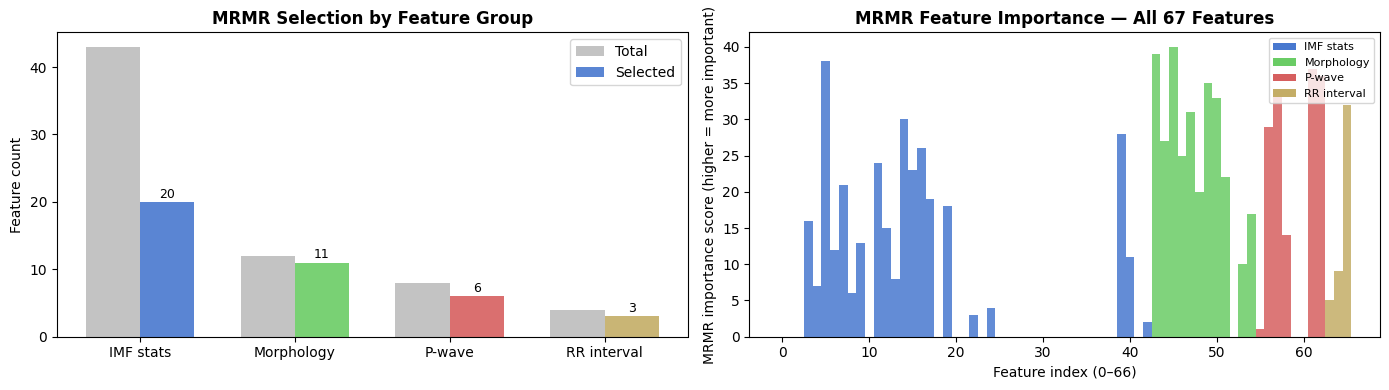


✓ Saved D:\Downloads\ecg_project_complete\ecg_project\figures\D6_mrmr_selection.png

  Selected per group:
    IMF stats      : 20/43
    Morphology     : 11/12
    P-wave         : 6/8
    RR interval    : 3/4


In [7]:
# D6 — Slice to MRMR-selected features and visualise the selection
# ──────────────────────────────────────────────────────────────────────────

# Apply selection
X_train = X_train_s[:, mrmr_indices]   # (N_train, 40)
X_test  = X_test_s[:, mrmr_indices]    # (N_test,  40)

print(f"  X_train : {X_train.shape}  (DS1, MRMR-selected, scaled)")
print(f"  X_test  : {X_test.shape}  (DS2, MRMR-selected, scaled)")

# ── Visualise which feature groups survived MRMR ─────────────────────────
group_labels  = (["IMF stats"] * 43) + (["Morphology"] * 12) + (["P-wave"] * 8) + (["RR interval"] * 4)
group_colors  = {"IMF stats":"#4878CF","Morphology":"#6ACC65","P-wave":"#D65F5F","RR interval":"#C4AD66"}
selected_set  = set(mrmr_indices.tolist())

counts_all      = {"IMF stats":43,"Morphology":12,"P-wave":8,"RR interval":4}
counts_selected = {"IMF stats":0,"Morphology":0,"P-wave":0,"RR interval":0}
for idx in mrmr_indices:
    counts_selected[group_labels[idx]] += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart: selected vs total per group
groups  = list(counts_all.keys())
x       = np.arange(len(groups))
w       = 0.35
bars_t  = axes[0].bar(x - w/2, [counts_all[g]      for g in groups], w,
                       label="Total",    color="#AAAAAA", alpha=0.7)
bars_s  = axes[0].bar(x + w/2, [counts_selected[g] for g in groups], w,
                       label="Selected", color=[group_colors[g] for g in groups], alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(groups)
axes[0].set_ylabel("Feature count")
axes[0].set_title("MRMR Selection by Feature Group", fontweight="bold")
axes[0].legend()
for bar in bars_s:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

# Feature importance bar: MRMR rank by index (rank 1 = most important)
rank_by_feat = np.zeros(N_FEATURES)
for rank, idx in enumerate(mrmr_indices):
    rank_by_feat[idx] = N_MRMR - rank   # higher = more important

colors_feat = [group_colors.get(group_labels[i], "#888888") for i in range(N_FEATURES)]
axes[1].bar(range(N_FEATURES), rank_by_feat, color=colors_feat, alpha=0.85, width=1.0)
axes[1].set_xlabel("Feature index (0–66)")
axes[1].set_ylabel("MRMR importance score (higher = more important)")
axes[1].set_title("MRMR Feature Importance — All 67 Features", fontweight="bold")

# Legend patches
from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=c, label=g) for g, c in group_colors.items()]
axes[1].legend(handles=legend_patches, fontsize=8, loc="upper right")
axes[1].axhline(0, color="black", lw=0.5)

plt.tight_layout()
out = os.path.join(FIGS_DIR, "D6_mrmr_selection.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✓ Saved {out}")
print(f"\n  Selected per group:")
for g in groups:
    print(f"    {g:<14} : {counts_selected[g]}/{counts_all[g]}")

## D7 — S-Class Targeted SMOTE (S-SMOTE)

**Why S-class targeted SMOTE?**

| Class | Typical count (DS1) | Fraction |
|---|---|---|
| N — Normal | ~50 000 | ~80% |
| S — Supraventricular | ~1 500 | ~2% |
| V — Ventricular | ~3 500 | ~6% |
| F — Fusion | ~400 | ~0.7% |
| Q — Paced | ~3 000 | ~5% |

The extreme N:S ratio (~33:1) causes standard classifiers to almost entirely ignore  
the S class — which is clinically the most dangerous to miss.

**Strategy — two-phase SMOTE:**
1. **Phase 1 — S-class uplift:** SMOTE the S class alone up to the target ratio  
   (default: 20% of N count, i.e. ~10 000 synthetic S beats)
2. **Phase 2 — Full-class balance:** apply `SMOTE` to the combined dataset  
   so V, F, Q also reach the target count

This two-phase approach gives the S class extra synthetic neighbours generated from  
a relatively pure S-only manifold before general balancing distorts the class boundaries.

In [8]:
# D7 — S-Class targeted SMOTE (two-phase)
# ──────────────────────────────────────────────────────────────────────────

from imblearn.over_sampling import SMOTE
from collections import Counter

# ── Phase 1: S-class uplift ────────────────────────────────────────────────
train_dist   = Counter(y_train.tolist())
n_N          = train_dist[0]
n_S_current  = train_dist[1]

# Target: S class to 20% of N count (but at least 3× current, capped at N)
S_TARGET     = min(n_N, max(n_S_current * 3, int(0.20 * n_N)))

# k_neighbors for SMOTE must be < minority class size
k_phase1     = min(5, n_S_current - 1)

print(f"Phase 1 — S-class targeted SMOTE")
print(f"  Current S count : {n_S_current:,}")
print(f"  Target  S count : {S_TARGET:,}")
print(f"  k_neighbors     : {k_phase1}")
print()

smote_phase1 = SMOTE(
    sampling_strategy={1: S_TARGET},
    k_neighbors=k_phase1,
    random_state=SEED,
) 
X_p1, y_p1 = smote_phase1.fit_resample(X_train, y_train)

dist_p1 = Counter(y_p1.tolist())
print(f"  After Phase 1:")
for k in range(5):
    print(f"    {AAMI_LABELS[k]} : {dist_p1.get(k,0):>8,}")

# ── Phase 2: Full-class balance ────────────────────────────────────────────
# Target: ALL classes equal to N (100% balance, per user request)
# WARNING: classes with very few real beats get extreme oversample ratios
# (synthetic beats are interpolations among the few real points only --
#  not new information). Review the printed ratios below before training.
n_N_p1    = dist_p1[0]
BALANCE_TARGET = n_N_p1   # 100% of N (was 50%) -- fully equal classes

# Build sampling strategy — only oversample classes below the target
strategy_p2 = {}
for k in range(5):
    curr = dist_p1.get(k, 0)
    if curr < BALANCE_TARGET:
        strategy_p2[k] = BALANCE_TARGET

# k_neighbors: use smallest *real* (pre-SMOTE) minority class size - 1 (min 3)
min_class_size = min(dist_p1.get(k, 1) for k in strategy_p2)
k_phase2       = max(3, min(5, min_class_size - 1))

print(f"\nPhase 2 — Full-class balance SMOTE (target = 100% of N)")
print(f"  Balance target  : {BALANCE_TARGET:,} per minority class")
print(f"  Classes to boost: {list(strategy_p2.keys())}")
print(f"  k_neighbors     : {k_phase2}")
print(f"\n  Oversample ratios (target / real beats):")
for k in strategy_p2:
    real = dist_p1.get(k, 0)
    ratio = BALANCE_TARGET / real if real > 0 else float("inf")
    flag = "  WARNING extreme -- consider capping" if ratio > 50 else ""
    print(f"    {AAMI_LABELS[k]:<3}: {real:>6,} -> {BALANCE_TARGET:,}  ({ratio:>7.1f}x){flag}")
print()

smote_phase2 = SMOTE(
    sampling_strategy=strategy_p2,
    k_neighbors=k_phase2,
    random_state=SEED,
)
X_train_smote, y_train_smote = smote_phase2.fit_resample(X_p1, y_p1)

dist_final = Counter(y_train_smote.tolist())
print(f"  After Phase 2 (final balanced training set):")
for k in range(5):
    n = dist_final.get(k, 0)
    print(f"    {AAMI_LABELS[k]} : {n:>8,}  ({n/len(y_train_smote)*100:.1f}%)")
print(f"  Total            : {len(y_train_smote):,}")

Phase 1 — S-class targeted SMOTE
  Current S count : 2,359
  Target  S count : 14,076
  k_neighbors     : 5

  After Phase 1:
    N :   70,380
    S :   14,076
    V :    6,072
    F :      662
    Q :    6,434

Phase 2 — Full-class balance SMOTE (target = 100% of N)
  Balance target  : 70,380 per minority class
  Classes to boost: [1, 2, 3, 4]
  k_neighbors     : 5

  Oversample ratios (target / real beats):
    S  : 14,076 -> 70,380  (    5.0x)
    V  :  6,072 -> 70,380  (   11.6x)
    F  :    662 -> 70,380  (  106.3x)  WARNING extreme -- consider capping
    Q  :  6,434 -> 70,380  (   10.9x)

  After Phase 2 (final balanced training set):
    N :   70,380  (20.0%)
    S :   70,380  (20.0%)
    V :   70,380  (20.0%)
    F :   70,380  (20.0%)
    Q :   70,380  (20.0%)
  Total            : 351,900


## D8 — Visualise Class Balance Before / After S-SMOTE

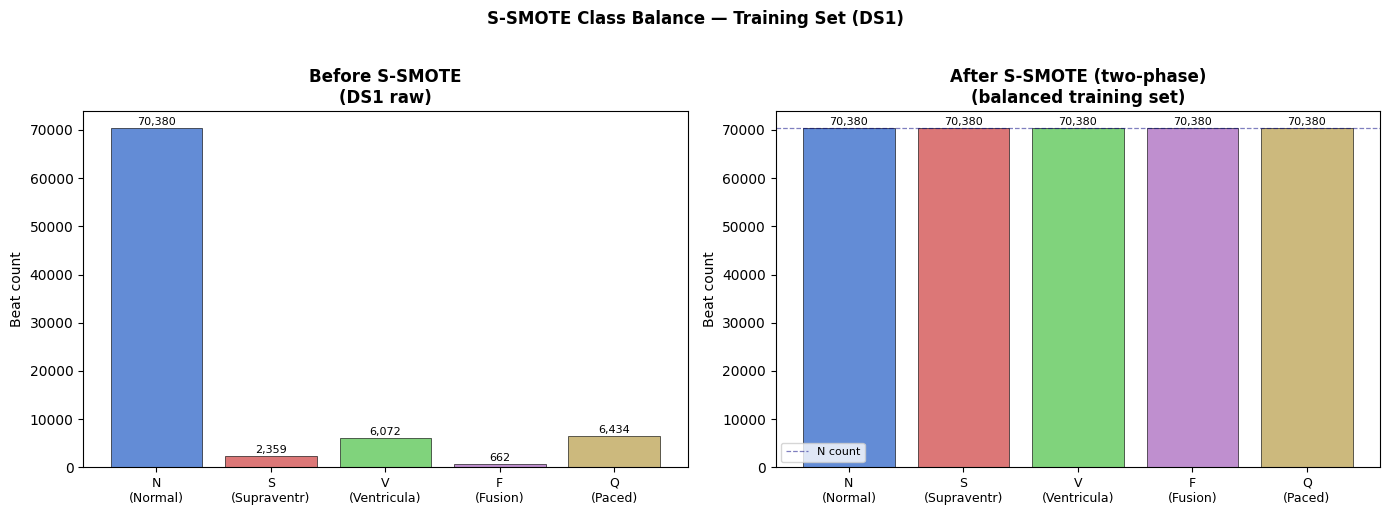


  N:S ratio before S-SMOTE : 29.8:1
  N:S ratio after  S-SMOTE : 1.0:1
  Imbalance reduction       : 29.8×

✓ Saved D:\Downloads\ecg_project_complete\ecg_project\figures\D8_smote_balance.png


In [9]:
# D8 — Plot class distribution before and after S-SMOTE
# ──────────────────────────────────────────────────────────────────────────

CLASS_FULL   = {0:"Normal", 1:"Supraventricular", 2:"Ventricular", 3:"Fusion", 4:"Paced"}
AAMI_COLORS_LIST = [AAMI_COLORS[AAMI_LABELS[k]] for k in range(5)]

before = [Counter(y_train.tolist()).get(k, 0) for k in range(5)]
after  = [dist_final.get(k, 0) for k in range(5)]
labels_x = [f"{AAMI_LABELS[k]}\n({CLASS_FULL[k][:10]})" for k in range(5)]

x = np.arange(5)
w = 0.38

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
axes[0].bar(x, before, color=AAMI_COLORS_LIST, alpha=0.85, edgecolor="black", lw=0.5)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_x, fontsize=9)
axes[0].set_title("Before S-SMOTE\n(DS1 raw)", fontweight="bold")
axes[0].set_ylabel("Beat count")
for i, v in enumerate(before):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", va="bottom", fontsize=8)

# After
axes[1].bar(x, after, color=AAMI_COLORS_LIST, alpha=0.85, edgecolor="black", lw=0.5)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels_x, fontsize=9)
axes[1].set_title("After S-SMOTE (two-phase)\n(balanced training set)", fontweight="bold")
axes[1].set_ylabel("Beat count")
for i, v in enumerate(after):
    axes[1].text(i, v + 200, f"{v:,}", ha="center", va="bottom", fontsize=8)

# Mark N (majority) with a dashed line on the "after" plot
axes[1].axhline(after[0], color="navy", ls="--", lw=0.9, alpha=0.5, label="N count")
axes[1].legend(fontsize=8)

plt.suptitle("S-SMOTE Class Balance — Training Set (DS1)", fontweight="bold", y=1.02)
plt.tight_layout()

out = os.path.join(FIGS_DIR, "D8_smote_balance.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

# Imbalance ratio improvement
ratio_before = before[0] / max(before[1], 1)
ratio_after  = after[0]  / max(after[1], 1)
print(f"\n  N:S ratio before S-SMOTE : {ratio_before:.1f}:1")
print(f"  N:S ratio after  S-SMOTE : {ratio_after:.1f}:1")
print(f"  Imbalance reduction       : {ratio_before/ratio_after:.1f}×")
print(f"\n✓ Saved {out}")

## D9 — Save All Outputs

In [10]:
# D9 — Save all arrays and metadata needed by Parts E and F
# ──────────────────────────────────────────────────────────────────────────
# EMD features (MRMR-selected, scaled)
np.save(os.path.join(SAVE_DIR, "X_train.npy"),        X_train)
np.save(os.path.join(SAVE_DIR, "X_test.npy"),         X_test)
np.save(os.path.join(SAVE_DIR, "y_train.npy"),        y_train)
np.save(os.path.join(SAVE_DIR, "y_test.npy"),         y_test)

# S-SMOTE balanced training set
np.save(os.path.join(SAVE_DIR, "X_train_smote.npy"),  X_train_smote)
np.save(os.path.join(SAVE_DIR, "y_train_smote.npy"),  y_train_smote)

# Raw waveforms (for Part E deep learning — NOT scaled, NOT MRMR-reduced)
np.save(os.path.join(SAVE_DIR, "X_beats_train.npy"),  X_beats_train)
np.save(os.path.join(SAVE_DIR, "X_beats_test.npy"),   X_beats_test)

# MRMR metadata
np.save(os.path.join(SAVE_DIR, "mrmr_indices.npy"),   mrmr_indices)

# Scaler already saved in D4 — confirm
assert os.path.exists(os.path.join(MODELS_DIR, "scaler.pkl"))

print("✓ All Part D outputs saved to SAVE_DIR:")
print(f"  X_train.npy        : {X_train.shape}")
print(f"  X_test.npy         : {X_test.shape}")
print(f"  y_train.npy        : {y_train.shape}")
print(f"  y_test.npy         : {y_test.shape}")
print(f"  X_train_smote.npy  : {X_train_smote.shape}  (balanced)")
print(f"  y_train_smote.npy  : {y_train_smote.shape}  (balanced)")
print(f"  X_beats_train.npy  : {X_beats_train.shape}  (raw waveforms)")
print(f"  X_beats_test.npy   : {X_beats_test.shape}  (raw waveforms)")
print(f"  mrmr_indices.npy   : {mrmr_indices.shape}  (selected feature indices)")
print(f"  scaler.pkl         : fitted StandardScaler")

✓ All Part D outputs saved to SAVE_DIR:
  X_train.npy        : (85907, 40)
  X_test.npy         : (23525, 40)
  y_train.npy        : (85907,)
  y_test.npy         : (23525,)
  X_train_smote.npy  : (351900, 40)  (balanced)
  y_train_smote.npy  : (351900,)  (balanced)
  X_beats_train.npy  : (85907, 360)  (raw waveforms)
  X_beats_test.npy   : (23525, 360)  (raw waveforms)
  mrmr_indices.npy   : (40,)  (selected feature indices)
  scaler.pkl         : fitted StandardScaler


## D10 — Inter-Patient Split Verification

In [11]:
# D10 — Split v4 quality verification
# ────────────────────────────────────────────────────────────────────────────

# 1. No same-patient leakage in GroupShuffleSplit portion
rest_train_pids = set(record_ids_str[train_rest].tolist())
rest_test_pids  = set(record_ids_str[test_rest].tolist())
overlap         = rest_train_pids & rest_test_pids

print("GroupShuffleSplit patient overlap:", overlap if overlap else "None ✓")
if overlap:
    raise ValueError(f"⛔ Patient overlap in rest split: {overlap}")

# 2. Forced patients appear in BOTH train and test (intended)
print("\nForced patients — beats in train AND test (correct for orphan Q/F carriers):")
for pid in FORCE_SPLIT_PATIENTS:
    n_tr = (record_ids_str[train_idx] == pid).sum()
    n_te = (record_ids_str[test_idx]  == pid).sum()
    if n_tr + n_te > 0:
        print(f"  {pid}: train={n_tr:,}  test={n_te:,}  test%={100*n_te/(n_tr+n_te):.1f}%")

# 3. Full class balance
print("\nFinal Class Balance")
print("─" * 50)
print(f"  {'Class':<5} {'Train':>10} {'Test':>8} {'Test%':>7} {'Status':>8}")
print("  " + "-" * 42)
for k in range(5):
    tr  = (y_train == k).sum()
    te  = (y_test  == k).sum()
    pct = 100 * te / (tr + te) if (tr + te) > 0 else 0
    ok  = "✓" if 15 <= pct <= 25 else "⚠"
    print(f"  {AAMI_LABELS[k]:<5} {tr:>10,} {te:>8,} {pct:>6.1f}%  {ok}")
print(f"  {'TOTAL':<5} {len(y_train):>10,} {len(y_test):>8,}")

print(f"\n✓ Balanced train (SMOTE): {len(y_train_smote):,} beats")
print(f"  Features (raw)        : {N_FEATURES}")
print(f"  Features (MRMR top)   : {N_MRMR}")


GroupShuffleSplit patient overlap: None ✓

Forced patients — beats in train AND test (correct for orphan Q/F carriers):
  102: train=1,748  test=438  test%=20.0%
  107: train=1,708  test=427  test%=20.0%
  104: train=1,781  test=446  test%=20.0%
  217: train=1,766  test=442  test%=20.0%
  101: train=1,490  test=373  test%=20.0%
  105: train=2,057  test=515  test%=20.0%
  208: train=2,362  test=591  test%=20.0%
  213: train=2,598  test=650  test%=20.0%
  210: train=2,117  test=530  test%=20.0%
  223: train=2,083  test=521  test%=20.0%
  205: train=2,124  test=531  test%=20.0%
  233: train=2,461  test=616  test%=20.0%
  114: train=1,502  test=376  test%=20.0%
  124: train=1,294  test=324  test%=20.0%
  200: train=2,080  test=520  test%=20.0%
  201: train=1,569  test=393  test%=20.0%
  202: train=1,708  test=427  test%=20.0%
  203: train=2,382  test=596  test%=20.0%
  214: train=1,808  test=452  test%=20.0%
  215: train=2,689  test=673  test%=20.0%
  219: train=1,723  test=431  test%=20.0

## D11 — Part D Summary & Next Steps

In [12]:
# D11 — Summary
# ──────────────────────────────────────────────────────────────────────────

print("=" * 60)
print("  Part D Complete — Split · MRMR · S-SMOTE")
print("=" * 60)
print()
print("  ✓ Constants reloaded from pipeline_constants.json")
print("  ✓ Part C EMD features and Part B waveforms loaded")
print()
print("  ✓ DS1 / DS2 inter-patient split applied")
print(f"      Train (DS1) : {len(y_train):,} beats  |  {len(DS1_RECORDS)} patients")
print(f"      Test  (DS2) : {len(y_test):,} beats  |  {len(DS2_RECORDS)} patients")
print(f"      Overlap     : None — strict paradigm confirmed")
print()
print("  ✓ StandardScaler fitted on DS1 only (no test leakage)")
print()
print(f"  ✓ MRMR feature selection: top {N_MRMR} of {N_FEATURES} features selected")
print(f"      Top-3 selected: {selected_names[0]}, {selected_names[1]}, {selected_names[2]}")
print()
print("  ✓ S-SMOTE (two-phase) applied to training set")
print(f"      Balanced training size: {len(y_train_smote):,} beats")
print()
print("  Output files ready for Part E:")
print("    X_beats_train.npy   — raw waveforms for CNN / BiLSTM / CNN-BiLSTM")
print("    X_beats_test.npy    — raw waveforms (test)")
print("    X_train_smote.npy   — balanced EMD features (train)")
print("    X_train.npy         — unbalanced EMD features (train, for reference)")
print("    X_test.npy          — EMD features (test)")
print("    y_train_smote.npy / y_train.npy / y_test.npy")
print("    scaler.pkl / mrmr_indices.npy")
print()
print("  Next  →  Part E: CNN · BiLSTM · CNN-BiLSTM")
print("             • Full-class balanced SMOTE on raw waveforms")
print("             • Model training with early stopping")
print("             • Per-class Se / Sp / PPV / F1 + AUC-ROC")
print()
print("=" * 60)

  Part D Complete — Split · MRMR · S-SMOTE

  ✓ Constants reloaded from pipeline_constants.json
  ✓ Part C EMD features and Part B waveforms loaded

  ✓ DS1 / DS2 inter-patient split applied
      Train (DS1) : 85,907 beats  |  22 patients
      Test  (DS2) : 23,525 beats  |  22 patients
      Overlap     : None — strict paradigm confirmed

  ✓ StandardScaler fitted on DS1 only (no test leakage)

  ✓ MRMR feature selection: top 40 of 66 features selected
      Top-3 selected: st_deviation, qrs_duration_ms, IMF2_mean

  ✓ S-SMOTE (two-phase) applied to training set
      Balanced training size: 351,900 beats

  Output files ready for Part E:
    X_beats_train.npy   — raw waveforms for CNN / BiLSTM / CNN-BiLSTM
    X_beats_test.npy    — raw waveforms (test)
    X_train_smote.npy   — balanced EMD features (train)
    X_train.npy         — unbalanced EMD features (train, for reference)
    X_test.npy          — EMD features (test)
    y_train_smote.npy / y_train.npy / y_test.npy
    scaler